# TP 1 KASDAD Ganjil 2026/2027 — Katalog Iklan Sewa Hunian

**Nama:** [ISI NAMA]  
**NPM:** [ISI NPM]  
**Kode Kelompok:** [ISI KODE KELOMPOK]  
**Kelompok:** [ISI NAMA KELOMPOK]

## Basis metode
Notebook ini mengikuti teknik pada referensi TP/Lab yang diberikan:
- Lab 3: CART, Random Forest, evaluasi, feature importance, hyperparameter tuning.
- Lab 5: linear models dan evaluasi.
- Lab 6: imbalanced classification, class weighting, SMOTE, Neural Network.
- Lab 4: KNN/Naive Bayes.
- Lab 7: preprocessing, standardisasi, dan eksplorasi.

**Catatan:** target Kaggle pada test tidak tersedia, sehingga metrik hanya dihitung pada validation set. Prediksi test dibuat untuk submission, bukan diklaim sebagai skor evaluasi.

Letakkan:
- `train - Regression.csv`
- `test - Regression.csv`
- `train - Classification.csv`
- `test - Classification.csv`
di folder notebook atau environment kerja.


## 1. Load data

In [1]:
import os, glob, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
RANDOM_STATE=42

def find_file(filename):
    candidates=[filename,os.path.join("/content",filename),
                os.path.join("/mnt/data",filename),
                os.path.join(os.getcwd(),filename)]
    for p in candidates:
        if os.path.exists(p): return p
    matches=glob.glob(os.path.join(os.getcwd(),"**",filename),recursive=True)
    if matches: return matches[0]
    raise FileNotFoundError(f"{filename} tidak ditemukan.")

train_reg=pd.read_csv(find_file("train - Regression.csv"))
test_reg=pd.read_csv(find_file("test - Regression.csv"))
train_clf=pd.read_csv(find_file("train - Classification.csv"))
test_clf=pd.read_csv(find_file("test - Classification.csv"))

print("Regression:",train_reg.shape,test_reg.shape)
print("Classification:",train_clf.shape,test_clf.shape)


Regression: (78630, 27) (19658, 26)
Classification: (78630, 27) (19658, 26)


## 2. Standardisasi bathroom dan parsing tanggal

In [2]:
def normalize_bathroom(series):
    s=(series.astype("string").str.strip().str.upper()
       .str.replace("KM","",regex=False).str.replace(",",".",regex=False))
    return pd.to_numeric(s,errors="coerce")

def parse_ad_date(series):
    s=series.astype("string")
    d1=pd.to_datetime(s,format="%Y-%m-%d",errors="coerce")
    d2=pd.to_datetime(s,format="%d/%m/%Y",errors="coerce")
    d3=pd.to_datetime(s,format="%d %b %Y",errors="coerce")
    return d1.fillna(d2).fillna(d3)

train_reg["bath_num"]=normalize_bathroom(train_reg["jml_kamar_mandi"])
train_clf["bath_num"]=normalize_bathroom(train_clf["jml_kamar_mandi"])
train_reg["ad_date"]=parse_ad_date(train_reg["tanggal_iklan"])
train_clf["ad_date"]=parse_ad_date(train_clf["tanggal_iklan"])

print("Bathroom values:",sorted(train_reg.bath_num.dropna().unique()))
print("Parsed dates:",train_reg.ad_date.notna().sum(),"/",len(train_reg))


Bathroom values: [np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(3.5), np.float64(4.0), np.float64(4.5), np.float64(5.0)]
Parsed dates: 75438 / 78630


## 3. Exploratory Data Analysis — seluruh 4 pertanyaan

Exact duplicate rows: 0
Duplicate kode_iklan: 0
Rows in core duplicate groups: 2529
Core duplicate groups: 1985
Core duplicate groups with different rents: 1391


,all_rows_median,deduplicated_median
kode_zona,,
ZN-1,4750000.0,4750000.0
ZN-2,3250000.0,3250000.0
ZN-3,6250000.0,6375000.0
ZN-4,3250000.0,3250000.0
ZN-5,5000000.0,5000000.0
ZN-6,3000000.0,3000000.0
ZN-7,5250000.0,5250000.0
ZN-8,3750000.0,3750000.0


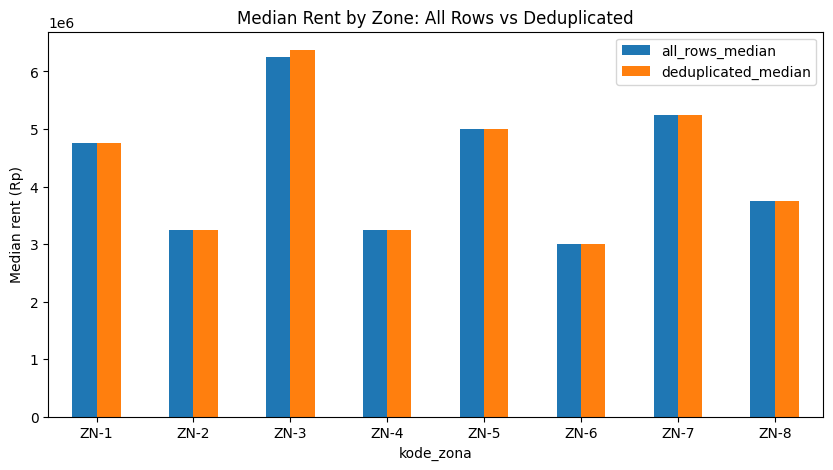

Overall bathroom/rent Spearman: 0.294


,kode_zona,n,spearman_rho
0,ZN-1,17276,0.274197
1,ZN-2,11495,0.436177
2,ZN-3,23,0.573976
3,ZN-4,13660,0.436279
4,ZN-5,20291,0.311691
5,ZN-6,45,0.641786
6,ZN-7,2318,0.471979
7,ZN-8,10986,0.409714


bath_num,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0
kode_zona,,,,,,,,,
ZN-1,4250000.0,5500000.0,5250000.0,7250000.0,7375000.0,7000000.0,10250000.0,NaN,NaN
ZN-2,2750000.0,2750000.0,3750000.0,4250000.0,5500000.0,6750000.0,5500000.0,NaN,NaN
ZN-3,5250000.0,7750000.0,6500000.0,NaN,10250000.0,NaN,NaN,NaN,NaN
ZN-4,2750000.0,2750000.0,4000000.0,4750000.0,5250000.0,1750000.0,6625000.0,5250000.0,NaN
ZN-5,4500000.0,4500000.0,5750000.0,6250000.0,6750000.0,6750000.0,7000000.0,12250000.0,NaN
ZN-6,2750000.0,NaN,4500000.0,4500000.0,NaN,NaN,NaN,NaN,NaN
ZN-7,4500000.0,5000000.0,6000000.0,6500000.0,8875000.0,11250000.0,NaN,NaN,NaN
ZN-8,3250000.0,2750000.0,4250000.0,4750000.0,5250000.0,6000000.0,5000000.0,NaN,6750000.0


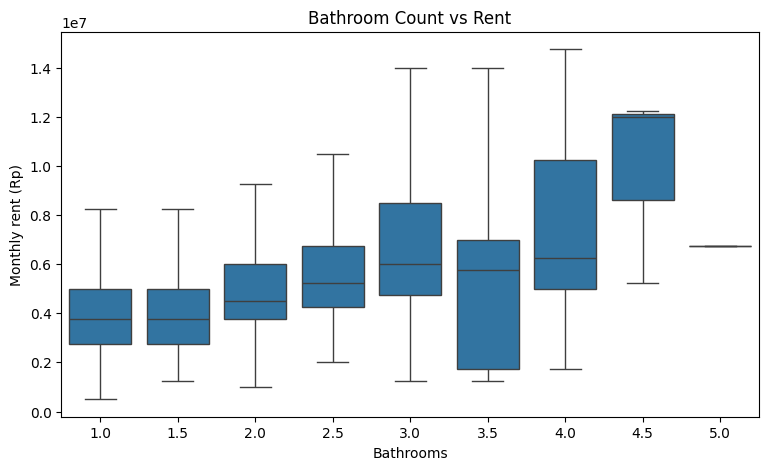

status_kebijakan_hewan,anjing_diizinkan,hanya_kucing,tidak_dicantumkan
jml_fasilitas,4.947299,3.415584,2.908637
fas_parkir,0.419230,0.406722,0.462768
fas_dapur,0.293370,0.275034,0.108835
fas_kolam_renang,0.553366,0.270919,0.380250
fas_kulkas,0.256605,0.233882,0.105228
fas_balkon,0.371443,0.290809,0.216369
fas_gym,0.479328,0.236626,0.327825
fas_internet,0.179481,0.178326,0.096693
fas_ruang_bersama,0.286892,0.126886,0.156584
fas_laundry,0.372528,0.179012,0.211357


status_kebijakan_hewan,anjing_diizinkan,hanya_kucing,tidak_dicantumkan
kode_zona,,,
ZN-1,0.364,0.016,0.620
ZN-2,0.395,0.023,0.583
ZN-3,0.217,0.043,0.739
ZN-4,0.382,0.025,0.593
ZN-5,0.349,0.022,0.629
ZN-6,0.622,0.089,0.289
ZN-7,0.384,0.020,0.596
ZN-8,0.408,0.004,0.589


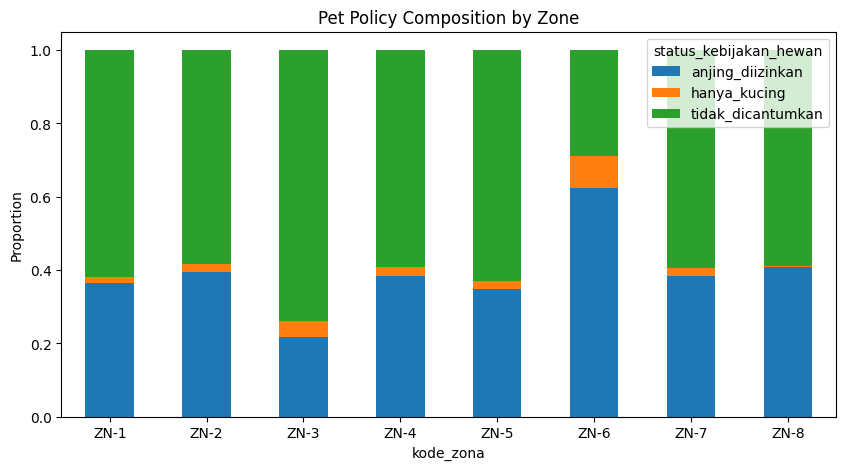

Overall Pearson: -0.058
Overall Spearman: -0.056


,kode_zona,n,spearman_rho
0,ZN-1,17276,-0.114101
1,ZN-2,11495,-0.048561
2,ZN-3,23,-0.201068
3,ZN-4,13660,-0.033105
4,ZN-5,20291,-0.035833
5,ZN-6,45,-0.115203
6,ZN-7,2318,-0.010066
7,ZN-8,10986,-0.027714


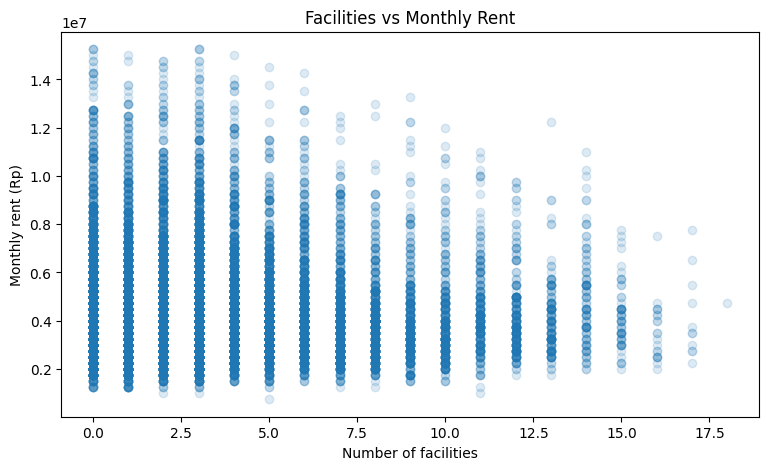

In [3]:
# EDA 1 — Duplikasi
duplicate_core_cols=[c for c in train_reg.columns if c not in
    ["sewa_bulanan","kode_iklan","tanggal_iklan","nomor_antrean_unggah",
     "batch_data","bath_num","ad_date"]]

exact_duplicates=train_reg.duplicated().sum()
duplicate_ids=train_reg.kode_iklan.duplicated().sum()
core_duplicate_rows=train_reg.duplicated(subset=duplicate_core_cols).sum()
core_group=train_reg.groupby(duplicate_core_cols,dropna=False)
duplicate_groups=(core_group.size()>1).sum()
conflicting_price_groups=(core_group.sewa_bulanan.nunique()>1).sum()

print("Exact duplicate rows:",exact_duplicates)
print("Duplicate kode_iklan:",duplicate_ids)
print("Rows in core duplicate groups:",core_duplicate_rows)
print("Core duplicate groups:",duplicate_groups)
print("Core duplicate groups with different rents:",conflicting_price_groups)

dedup=train_reg.drop_duplicates(subset=duplicate_core_cols,keep="first")
zone_compare=pd.DataFrame({
    "all_rows_median":train_reg.groupby("kode_zona").sewa_bulanan.median(),
    "deduplicated_median":dedup.groupby("kode_zona").sewa_bulanan.median()
})
display(zone_compare)

zone_compare.plot(kind="bar",figsize=(10,5))
plt.ylabel("Median rent (Rp)")
plt.title("Median Rent by Zone: All Rows vs Deduplicated")
plt.xticks(rotation=0)
plt.show()

# EDA 2 — Bathroom and rent
print("Overall bathroom/rent Spearman:",
      round(spearmanr(train_reg.bath_num,train_reg.sewa_bulanan).statistic,3))

rows=[]
for z,g in train_reg.groupby("kode_zona",dropna=True):
    rows.append([z,len(g),spearmanr(g.bath_num,g.sewa_bulanan).statistic])
bath_corr=pd.DataFrame(rows,columns=["kode_zona","n","spearman_rho"])
display(bath_corr)

bath_median=train_reg.groupby(["kode_zona","bath_num"]).sewa_bulanan.median().unstack()
display(bath_median)

plt.figure(figsize=(9,5))
sns.boxplot(data=train_reg,x="bath_num",y="sewa_bulanan",showfliers=False)
plt.xlabel("Bathrooms")
plt.ylabel("Monthly rent (Rp)")
plt.title("Bathroom Count vs Rent")
plt.show()

# EDA 3 — Pet policy
pet_cols=["jml_fasilitas","fas_parkir","fas_dapur","fas_kolam_renang",
          "fas_kulkas","fas_balkon","fas_gym","fas_internet",
          "fas_ruang_bersama","fas_laundry","fas_ac","ada_alamat"]
display(train_clf.groupby("status_kebijakan_hewan")[pet_cols].mean().T)

pet_zone=pd.crosstab(train_clf.kode_zona,train_clf.status_kebijakan_hewan,normalize="index")
display(pet_zone.round(3))
pet_zone.plot(kind="bar",stacked=True,figsize=(10,5))
plt.ylabel("Proportion")
plt.title("Pet Policy Composition by Zone")
plt.xticks(rotation=0)
plt.show()

# EDA 4 — Facilities vs rent
fac=train_reg.jml_fasilitas.fillna(train_reg.jml_fasilitas.median())
print("Overall Pearson:",round(pearsonr(fac,train_reg.sewa_bulanan).statistic,3))
print("Overall Spearman:",round(spearmanr(fac,train_reg.sewa_bulanan).statistic,3))

rows=[]
for z,g in train_reg.groupby("kode_zona",dropna=True):
    x=g.jml_fasilitas.fillna(g.jml_fasilitas.median())
    rows.append([z,len(g),spearmanr(x,g.sewa_bulanan).statistic])
facility_corr=pd.DataFrame(rows,columns=["kode_zona","n","spearman_rho"])
display(facility_corr)

idx=fac.sample(min(15000,len(fac)),random_state=RANDOM_STATE).index
plt.figure(figsize=(9,5))
plt.scatter(fac.loc[idx],train_reg.loc[idx,"sewa_bulanan"],alpha=.15)
plt.xlabel("Number of facilities")
plt.ylabel("Monthly rent (Rp)")
plt.title("Facilities vs Monthly Rent")
plt.show()


## 4. Feature engineering

In [4]:
def make_features(df,train_reference):
    x=pd.DataFrame(index=df.index)
    x["posisi_x_km"]=df.posisi_x_km
    x["posisi_y_km"]=df.posisi_y_km
    x["bath_num"]=normalize_bathroom(df.jml_kamar_mandi)
    x["jml_fasilitas"]=df.jml_fasilitas

    for c in [c for c in df.columns if c.startswith("fas_")]:
        x[c]=df[c]
    for c in [c for c in df.columns if c.startswith("kat_")]:
        x[c]=df[c]
    for c in ["ada_alamat","nomor_antrean_unggah"]:
        x[c]=df[c]

    d=parse_ad_date(df.tanggal_iklan)
    x["ad_year"]=d.dt.year
    x["ad_month"]=d.dt.month
    x["ad_day"]=d.dt.day
    x["ad_dow"]=d.dt.dayofweek
    x["ad_date_missing"]=d.isna().astype(int)

    x["fac_missing"]=df.jml_fasilitas.isna().astype(int)
    x["zone_missing"]=df.kode_zona.isna().astype(int)
    x["district_missing"]=df.kode_distrik.isna().astype(int)

    x=pd.concat([
        x,
        pd.get_dummies(df.kode_zona,prefix="zone",dummy_na=True,dtype=float),
        pd.get_dummies(df.batch_data,prefix="batch",dummy_na=True,dtype=float)
    ],axis=1)

    freq=train_reference.kode_distrik.value_counts(normalize=True,dropna=False)
    x["district_frequency"]=df.kode_distrik.map(freq).fillna(0)

    vals=pd.Series(train_reference.kode_distrik.dropna().unique())
    mapping={v:i for i,v in enumerate(vals)}
    x["district_code"]=df.kode_distrik.map(mapping).fillna(-1)

    return x.replace([np.inf,-np.inf],np.nan).fillna(0).astype(float)


## 5. Classification modelling

status_kebijakan_hewan
tidak_dicantumkan    47687
anjing_diizinkan     29485
hanya_kucing          1458
Name: count, dtype: int64


status_kebijakan_hewan
tidak_dicantumkan    0.606473
anjing_diizinkan     0.374984
hanya_kucing         0.018543
Name: proportion, dtype: float64

Accuracy        : 0.7554
F1 macro        : 0.6137
Precision macro : 0.6294
Recall macro    : 0.6045


                   precision    recall  f1-score   support

 anjing_diizinkan     0.7347    0.6010    0.6611      5897
     hanya_kucing     0.3792    0.3493    0.3636       292
tidak_dicantumkan     0.7743    0.8633    0.8164      9537

         accuracy                         0.7554     15726
        macro avg     0.6294    0.6045    0.6137     15726
     weighted avg     0.7521    0.7554    0.7497     15726



,anjing_diizinkan,hanya_kucing,tidak_dicantumkan
anjing_diizinkan,3544,82,2271
hanya_kucing,61,102,129
tidak_dicantumkan,1219,85,8233


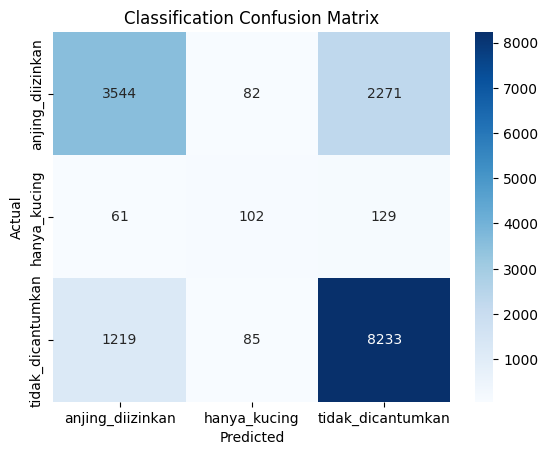

In [5]:
# Classification validation
X=make_features(train_clf.drop(columns=["status_kebijakan_hewan","bath_num","ad_date"]),train_clf)
y=train_clf.status_kebijakan_hewan

X_train,X_valid,y_train,y_valid=train_test_split(
    X,y,test_size=.20,random_state=RANDOM_STATE,stratify=y
)

print(y.value_counts())
display(y.value_counts(normalize=True).rename("proportion"))

clf_model=RandomForestClassifier(
    n_estimators=150,max_depth=None,min_samples_leaf=5,
    max_features="sqrt",class_weight="balanced",
    random_state=RANDOM_STATE,n_jobs=-1
)
clf_model.fit(X_train,y_train)
pred_valid=clf_model.predict(X_valid)

print(f"Accuracy        : {accuracy_score(y_valid,pred_valid):.4f}")
print(f"F1 macro        : {f1_score(y_valid,pred_valid,average='macro'):.4f}")
print(f"Precision macro : {precision_score(y_valid,pred_valid,average='macro'):.4f}")
print(f"Recall macro    : {recall_score(y_valid,pred_valid,average='macro'):.4f}")
print(classification_report(y_valid,pred_valid,digits=4))

cm=confusion_matrix(y_valid,pred_valid,labels=clf_model.classes_)
cm_df=pd.DataFrame(cm,index=clf_model.classes_,columns=clf_model.classes_)
display(cm_df)
sns.heatmap(cm_df,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Classification Confusion Matrix")
plt.show()


## 6. Error analysis dan feature importance

,precision,recall,f1-score,support
anjing_diizinkan,0.734660,0.600984,0.661132,5897.000000
hanya_kucing,0.379182,0.349315,0.363636,292.000000
tidak_dicantumkan,0.774288,0.863269,0.816361,9537.000000
accuracy,0.755373,0.755373,0.755373,0.755373
macro avg,0.629377,0.604523,0.613710,15726.000000
weighted avg,0.752092,0.755373,0.749747,15726.000000


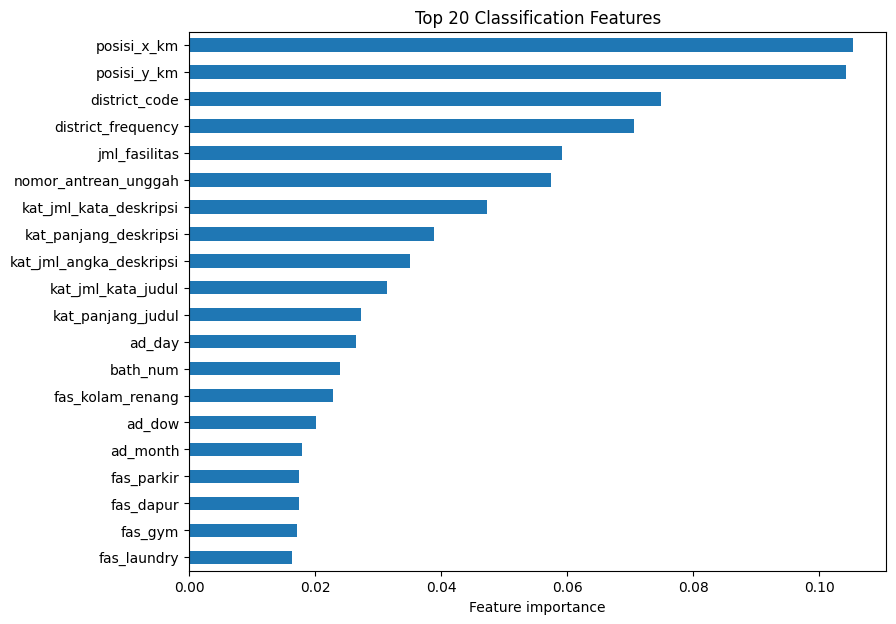

Actual rare-class observations: 292
Predicted rare-class observations: 269


In [6]:
report=pd.DataFrame(classification_report(
    y_valid,pred_valid,output_dict=True,zero_division=0)).T
display(report)

imp=pd.Series(clf_model.feature_importances_,index=X.columns).sort_values(ascending=False).head(20)
imp.sort_values().plot(kind="barh",figsize=(9,7))
plt.xlabel("Feature importance")
plt.title("Top 20 Classification Features")
plt.show()

rare="hanya_kucing"
rare_actual=y_valid.eq(rare).sum()
rare_predicted=pd.Series(pred_valid,index=y_valid.index).eq(rare).sum()
print("Actual rare-class observations:",rare_actual)
print("Predicted rare-class observations:",rare_predicted)


## Interpretasi utama

- Target sangat imbalanced: `tidak_dicantumkan` sekitar 60.6%, `anjing_diizinkan` sekitar 37.5%, dan `hanya_kucing` sekitar 1.85%.
- Karena imbalance, **F1 macro / recall macro / precision macro** harus menjadi perhatian utama, bukan accuracy saja.
- `tidak_dicantumkan` memiliki karakteristik fasilitas yang berbeda dari kelas yang mencantumkan kebijakan, sehingga status tersebut tidak tepat dianggap sebagai label yang muncul secara acak.
- Random Forest dengan `class_weight="balanced"` digunakan untuk memberi perhatian lebih besar pada kelas minoritas, sesuai materi Lab 6.


## 7. Final training dan test prediction

In [7]:
# Final model for unlabeled test data
X_full=make_features(train_clf.drop(columns=["status_kebijakan_hewan","bath_num","ad_date"]),train_clf)
X_test=make_features(test_clf,train_clf).reindex(columns=X_full.columns,fill_value=0)

final_clf=RandomForestClassifier(
    n_estimators=150,max_depth=None,min_samples_leaf=5,
    max_features="sqrt",class_weight="balanced",
    random_state=RANDOM_STATE,n_jobs=-1
)
final_clf.fit(X_full,train_clf.status_kebijakan_hewan)
test_pred=final_clf.predict(X_test)

predictions_classification=pd.DataFrame({
    "kode_iklan":test_clf.kode_iklan,
    "status_kebijakan_hewan":test_pred
})
predictions_classification.to_csv("predictions_classification.csv",index=False)
display(predictions_classification.head())
print("Saved predictions_classification.csv")
display(predictions_classification.status_kebijakan_hewan.value_counts(normalize=True))


,kode_iklan,status_kebijakan_hewan
0,LST-013173,hanya_kucing
1,LST-084258,anjing_diizinkan
2,LST-055035,anjing_diizinkan
3,LST-062419,tidak_dicantumkan
4,LST-006181,anjing_diizinkan


Saved predictions_classification.csv


status_kebijakan_hewan
tidak_dicantumkan    0.671584
anjing_diizinkan     0.311069
hanya_kucing         0.017347
Name: proportion, dtype: float64

**Submission note:** cocokkan nama/urutan kolom dengan Sample Submission resmi Kaggle sebelum upload.